# **Edge Detector — interactive demo (users)**

## Libraries

In [1]:
import numpy as np, matplotlib.pyplot as plt, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

from core.config import LayoutConfig, GlobalConfig
from operators.image_io import ImageIO
from operators.edge_detector import edge_detect
from utils.nd_tools import show_plane  # helper for plane visualization
from utils.decorators import timer # helper for benchmarking

## Configurations

In [2]:
# ImageIO configuration: NumPy input/output, HWC layout
layout_cfg = LayoutConfig(layout_name="HWC", layout_framework="numpy", layout_ensured_name="HWC")
global_cfg  = GlobalConfig(framework="numpy", output_format="numpy")
io = ImageIO(layout_cfg=layout_cfg, global_cfg=global_cfg)

print("Initialized ImageIO — framework:", global_cfg.framework, "| output:", global_cfg.output_format)

Initialized ImageIO — framework: numpy | output: numpy


## Image Directory

In [3]:
root = Path.cwd().parent.parent.parent / "03_EXAMPLES_DATA" / "Images"
images_path = sorted([str(p) for p in root.rglob("*.png")])
rand = random.randint(0, len(images_path) - 2)
print("Found images:", len(images_path))

Found images: 672


## Load random image and build runners

In [4]:
image = io.read_image(images_path[rand], framework="numpy")

edge_strategy, cmap = "gradient", "inferno" # marr_hildreth, canny, laplacian, combined

@timer(return_result=True, name = edge_strategy)
def run_edge(strategy, diff="vectorized", proc="vectorized", conv="gaussian", fw="numpy", out="numpy"):
    return edge_detect(
        image,
        edge_strategy=strategy,
        diff_strategy=diff,
        processor_strategy=proc,
        conv_strategy=conv,
        framework=fw,
        output_format=out
    )
print("Running edge detection...\n")   
print("Vectorized process")    
res_vectorized = run_edge(edge_strategy,"vectorized")
print("Vectorized process done.\n")
print("Classic process")
res_classic    = run_edge(edge_strategy,"classic")
print("Classic process done.\n")
print("Torch process")
res_torch  = run_edge(edge_strategy,"torch","torch","torch","torch","numpy")
print("Torch process done.\n")
print("Parallel process")
res_parallel   = run_edge(edge_strategy,"parallel","parallel","gaussian")
print("Parallel process done.")

Running edge detection...

Vectorized process
Execution time for 'gradient': 0.397 seconds
Vectorized process done.

Classic process
Execution time for 'gradient': 0.376 seconds
Classic process done.

Torch process
Execution time for 'gradient': 0.820 seconds
Torch process done.

Parallel process
Execution time for 'gradient': 0.360 seconds
Parallel process done.


## Visualisation

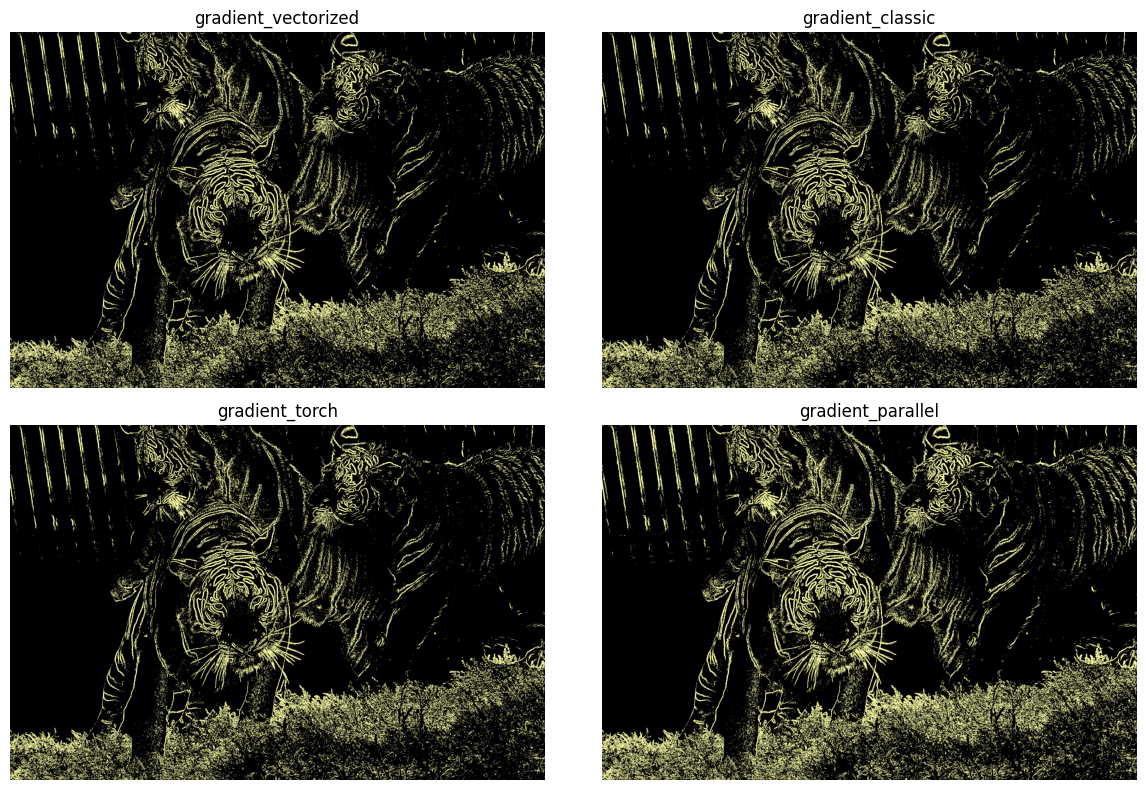

In [5]:
fig, ((a,b),(c,d)) = plt.subplots(2,2,figsize=(12,8))
show_plane(a, res_vectorized[...,0], title="gradient_vectorized", cmap=cmap)
show_plane(b, res_classic[...,0], title="gradient_classic", cmap=cmap)
show_plane(c, res_torch[...,0], title="gradient_torch", cmap=cmap)
show_plane(d, res_parallel[...,0], title="gradient_parallel", cmap=cmap)
plt.tight_layout(); plt.show()

## Stats

In [6]:
def stats(x):
    arr = np.asarray(x)
    return float(arr.mean()), float(arr.std()), float(arr.min()), float(arr.max())

def safe_stats(name, arr):
    if arr is None: 
        print(f"{name:>16}: n/a"); return
    m,s,mi,ma = stats(arr)
    print(f"{name:>16}: mean={m:.4g} | std={s:.4g} | min={mi:.4g} | max={ma:.4g}")

print(f"—————————————————————————————— {edge_strategy} stats ————————————————————————————————")
safe_stats("vectorized", res_vectorized)
safe_stats("classic",    res_classic)
safe_stats("torch",      res_torch)
safe_stats("parallel",   res_parallel)

—————————————————————————————— gradient stats ————————————————————————————————
      vectorized: mean=0.1274 | std=0.3334 | min=0 | max=1
         classic: mean=0.1274 | std=0.3334 | min=0 | max=1
           torch: mean=0.1274 | std=0.3334 | min=0 | max=1
        parallel: mean=0.1333 | std=0.3399 | min=0 | max=1
